In [1]:
# Import des bibliothèques nécessaires

import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [2]:
# Chemins vers les données

base_path = "../data/raw/mri_dataset_brain_cancer_oc/"


assert os.path.exists(base_path), "Dataset introuvable, voir README"

# Données labellisées
path_labeled = os.path.join(base_path, "avec_labels")
cancer_path = os.path.join(path_labeled, "cancer")
normal_path = os.path.join(path_labeled, "normal")

# Données non labellisées
path_unlabeled = os.path.join(base_path, "sans_label")

In [3]:
# Chargement des fichiers

cancer_files = os.listdir(cancer_path)
normal_files = os.listdir(normal_path)
unlabeled_files = os.listdir(path_unlabeled)

# Affichage des quantités
print("Images cancer :", len(cancer_files))
print("Images normal :", len(normal_files))
print("Images sans label :", len(unlabeled_files))

Images cancer : 50
Images normal : 50
Images sans label : 1406


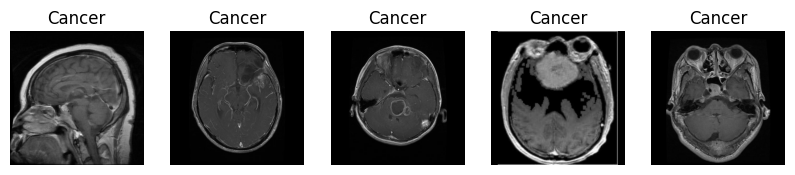

In [4]:
# Affichage d'exemples d'images cancer

plt.figure(figsize=(10,5))

for i in range(5):
    img = Image.open(os.path.join(cancer_path, cancer_files[i]))
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title("Cancer")
    plt.axis('off')

plt.show()

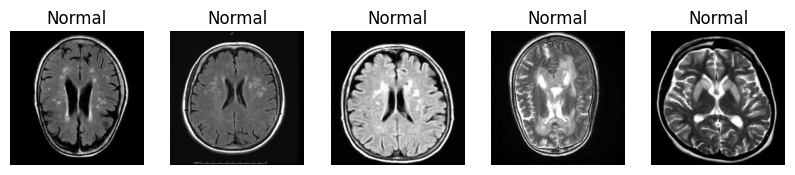

In [5]:
# Affichage d'exemples d'images normales

plt.figure(figsize=(10,5))

for i in range(5):
    img = Image.open(os.path.join(normal_path, normal_files[i]))
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title("Normal")
    plt.axis('off')

plt.show()

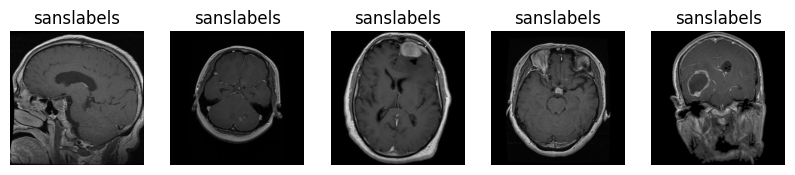

In [6]:
# Affichage d'exemples d'images non labellisées

plt.figure(figsize=(10,5))

for i in range(5):
    img = Image.open(os.path.join(path_unlabeled, unlabeled_files[i]))
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title("sanslabels")
    plt.axis('off')

plt.show()

In [7]:
# Analyse d'une image exemple

img = Image.open(os.path.join(cancer_path, cancer_files[0]))

print("Taille :", img.size)
print("Mode :", img.mode)

Taille : (512, 512)
Mode : RGB


In [8]:
# Récupération de toutes les tailles

sizes = []

for f in cancer_files:
    img = Image.open(os.path.join(cancer_path, f))
    sizes.append(img.size)

for f in normal_files:
    img = Image.open(os.path.join(normal_path, f))
    sizes.append(img.size)

for f in unlabeled_files:
    img = Image.open(os.path.join(path_unlabeled, f))
    sizes.append(img.size)

print("Exemples tailles :", sizes[:10])
print("Nombre de tailles différentes :", len(set(sizes)))

Exemples tailles : [(512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]
Nombre de tailles différentes : 1


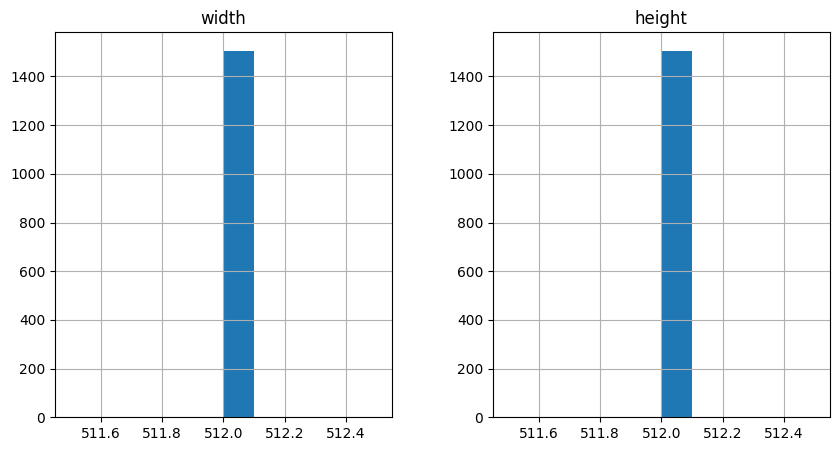

In [9]:
import pandas as pd

df_sizes = pd.DataFrame(sizes, columns=["width", "height"])
df_sizes.hist(figsize=(10,5))
plt.show()

## Analyse du dataset

Le dataset contient **1506 images de cerveau**, réparties comme suit :

- **Images labellisées :**
  - Classe *cancer* : 50 images
  - Classe *normal* : 50 images  

- **Images non labellisées :**
  - 1406 images sans annotation

---

### Structure des données

Le dataset est organisé de la manière suivante :

data/raw/mri_dataset_brain_cancer_oc/
├── avec_labels/
│   ├── cancer/
│   └── normal/
└── sans_label/

Cette organisation permet de distinguer les données annotées et non annotées, ce qui est adapté à une approche semi-supervisée.

---

### Caractéristiques des images

- Les images sont chargées en **RGB**, mais leur contenu est en **niveaux de gris**
- Les dimensions des images sont **homogènes (512x512 pixels)**
- La qualité des images est globalement **bonne**, avec peu de bruit
- Les différences visuelles entre les classes *cancer* et *normal* ne sont pas toujours évidentes

---

### Implications pour le projet

- Un prétraitement sera nécessaire :
  - redimensionnement des images en **224x224**
  - normalisation des pixels

- La présence d’un grand nombre d’images non labellisées permet d’utiliser une approche **semi-supervisée**, en combinant :
  - apprentissage supervisé sur les données annotées
  - exploitation des données non annotées

---

### Reproductibilité

Les données ne sont pas incluses dans ce dépôt en raison de leur taille.

Pour reproduire ce projet :

1. Télécharger le dataset
2. Extraire le contenu dans le dossier suivant :

data/raw/

3. Vérifier que la structure des dossiers correspond à celle décrite ci-dessus

---

### Conclusion

Ce dataset est adapté à une tâche de **classification d’images médicales** dans un contexte réaliste où les données annotées sont limitées.

Il constitue une base pertinente pour appliquer des méthodes de :
- clustering
- apprentissage semi-supervisé